# Central question

**"What behavioral patterns distinguish high-value players from lower-value players, beyond their overall engagement and monetization levels?"**

## In terms of
- Purchase Timing: `FirstPurchaseDaysAfterInstall`
- Purchase Recency `LastPurchaseDate`

## Inital Setup

In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = df = pd.read_csv("../data/game_data_clean.csv")
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3024 entries, 0 to 3023
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   UserID                         3024 non-null   object 
 1   Age                            2964 non-null   float64
 2   Gender                         2964 non-null   object 
 3   Country                        2964 non-null   object 
 4   Device                         2964 non-null   object 
 5   GameGenre                      2964 non-null   object 
 6   SessionCount                   3024 non-null   int64  
 7   AverageSessionLength           3024 non-null   float64
 8   SpendingSegment                3024 non-null   object 
 9   InAppPurchaseAmount            2888 non-null   float64
 10  FirstPurchaseDaysAfterInstall  2888 non-null   float64
 11  PaymentMethod                  2888 non-null   object 
 12  LastPurchaseDate               2888 non-null   o

In [94]:
# Create the dataset
behavior_df = df[
    [
        "UserID",
        "SessionCount",
        "AverageSessionLength",
        "InAppPurchaseAmount",
        "FirstPurchaseDaysAfterInstall",
        "LastPurchaseDate",
        "GameGenre",
        "SpendingSegment"
    ]
].copy()

In [95]:
# Recreate the monetization variable
behavior_df["LogRevenue"] = np.log1p(
    behavior_df["InAppPurchaseAmount"]
)

In [96]:
# Recreate Engagement Score
behavior_df["SessionCount_Z"] = (
    behavior_df["SessionCount"] - behavior_df["SessionCount"].mean()
) / behavior_df["SessionCount"].std()

behavior_df["SessionLength_Z"] = (
    behavior_df["AverageSessionLength"] - behavior_df["AverageSessionLength"].mean()
) / behavior_df["AverageSessionLength"].std()

behavior_df["EngagementScore"] = (
    behavior_df["SessionCount_Z"] +
    behavior_df["SessionLength_Z"]
) / 2

In [97]:
# Recreate Behavioral Segment

analysis_df = behavior_df.dropna(
    subset=[
        "EngagementScore",
        "LogRevenue",
        "GameGenre"
    ]
).copy()

analysis_df

,UserID,SessionCount,AverageSessionLength,InAppPurchaseAmount,FirstPurchaseDaysAfterInstall,LastPurchaseDate,GameGenre,SpendingSegment,LogRevenue,SessionCount_Z,SessionLength_Z,EngagementScore
0,c9889ab0-9cfc-4a75-acd9-5eab1df0015c,9,12.83,11.40,28.0,2025-03-19,Battle Royale,Minnow,2.517696,-0.344924,-0.843774,-0.594349
1,7c9e413c-ecca-45f2-a780-2826a07952a2,11,19.39,6.37,18.0,2025-06-08,Action RPG,Minnow,1.997418,0.296953,-0.079669,0.108642
2,fd61e419-1a92-4f43-a8c7-135842ad328a,9,8.87,15.81,30.0,2025-06-02,Fighting,Minnow,2.821974,-0.344924,-1.305033,-0.824978
3,bdb7f6d1-ff9a-468c-afe7-43f32a94293e,12,19.56,13.49,9.0,2025-04-01,Racing,Minnow,2.673459,0.617891,-0.059868,0.279012
4,aa7eec14-4846-47b9-b879-9c98038cda04,10,15.23,10.86,15.0,2025-05-05,Battle Royale,Minnow,2.473171,-0.023985,-0.564224,-0.294105
...,...,...,...,...,...,...,...,...,...,...,...,...
3019,29f9fea9-591d-4e9f-a662-958655d3eb4a,7,34.81,12.48,16.0,2025-05-28,Fighting,Minnow,2.601207,-0.986801,1.716443,0.364821
3020,c906eb00-fb33-4bf2-97a4-311634cd0d7a,9,19.45,14.77,14.0,2025-07-25,Adventure,Minnow,2.758109,-0.344924,-0.072681,-0.208802
3021,26e17717-ebec-42a9-aae2-2eff66888119,15,20.54,16.69,24.0,2025-01-25,Card,Minnow,2.873000,1.580706,0.054282,0.817494
3022,4d6e2bfb-cb11-411a-942c-4fb7a4832088,8,14.48,17.29,15.0,2025-05-07,Fighting,Minnow,2.906354,-0.665862,-0.651583,-0.658723


In [98]:
# Use the same threshold in previous notebook
engagement_threshold = analysis_df["EngagementScore"].median()
revenue_threshold = analysis_df["LogRevenue"].median()

# Define segmentation logic
def classify_player(row):
    high_engagement = row["EngagementScore"] >= engagement_threshold
    high_monetization = row["LogRevenue"] >= revenue_threshold

    if high_engagement and high_monetization:
        return "High Engagement - High Monetization"
    elif high_engagement and not high_monetization:
        return "High Engagement - Low Monetization"
    elif not high_engagement and high_monetization:
        return "Low Engagement - High Monetization"
    else:
        return "Low Engagement - Low Monetization"

analysis_df["BehavioralSegment"] = analysis_df.apply(
    classify_player,
    axis=1
)
analysis_df["BehavioralSegment"]


0         Low Engagement - Low Monetization
1        High Engagement - Low Monetization
2        Low Engagement - High Monetization
3       High Engagement - High Monetization
4         Low Engagement - Low Monetization
                       ...                 
3019    High Engagement - High Monetization
3020     Low Engagement - High Monetization
3021    High Engagement - High Monetization
3022     Low Engagement - High Monetization
3023     High Engagement - Low Monetization
Name: BehavioralSegment, Length: 2831, dtype: object

## First Purchase Timing

In [99]:
# Create timing groups

analysis_df["FirstPurchaseTiming"]=pd.cut(analysis_df["FirstPurchaseDaysAfterInstall"],
bins=[-1, 3, 7, 14, 30],
labels=[
    "0-3 days",
    "4-7 days",
    "8-14 days",
    "15-30 days"
]
)
analysis_df

,UserID,SessionCount,AverageSessionLength,InAppPurchaseAmount,FirstPurchaseDaysAfterInstall,LastPurchaseDate,GameGenre,SpendingSegment,LogRevenue,SessionCount_Z,SessionLength_Z,EngagementScore,BehavioralSegment,FirstPurchaseTiming
0,c9889ab0-9cfc-4a75-acd9-5eab1df0015c,9,12.83,11.40,28.0,2025-03-19,Battle Royale,Minnow,2.517696,-0.344924,-0.843774,-0.594349,Low Engagement - Low Monetization,15-30 days
1,7c9e413c-ecca-45f2-a780-2826a07952a2,11,19.39,6.37,18.0,2025-06-08,Action RPG,Minnow,1.997418,0.296953,-0.079669,0.108642,High Engagement - Low Monetization,15-30 days
2,fd61e419-1a92-4f43-a8c7-135842ad328a,9,8.87,15.81,30.0,2025-06-02,Fighting,Minnow,2.821974,-0.344924,-1.305033,-0.824978,Low Engagement - High Monetization,15-30 days
3,bdb7f6d1-ff9a-468c-afe7-43f32a94293e,12,19.56,13.49,9.0,2025-04-01,Racing,Minnow,2.673459,0.617891,-0.059868,0.279012,High Engagement - High Monetization,8-14 days
4,aa7eec14-4846-47b9-b879-9c98038cda04,10,15.23,10.86,15.0,2025-05-05,Battle Royale,Minnow,2.473171,-0.023985,-0.564224,-0.294105,Low Engagement - Low Monetization,15-30 days
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3019,29f9fea9-591d-4e9f-a662-958655d3eb4a,7,34.81,12.48,16.0,2025-05-28,Fighting,Minnow,2.601207,-0.986801,1.716443,0.364821,High Engagement - High Monetization,15-30 days
3020,c906eb00-fb33-4bf2-97a4-311634cd0d7a,9,19.45,14.77,14.0,2025-07-25,Adventure,Minnow,2.758109,-0.344924,-0.072681,-0.208802,Low Engagement - High Monetization,8-14 days
3021,26e17717-ebec-42a9-aae2-2eff66888119,15,20.54,16.69,24.0,2025-01-25,Card,Minnow,2.873000,1.580706,0.054282,0.817494,High Engagement - High Monetization,15-30 days
3022,4d6e2bfb-cb11-411a-942c-4fb7a4832088,8,14.48,17.29,15.0,2025-05-07,Fighting,Minnow,2.906354,-0.665862,-0.651583,-0.658723,Low Engagement - High Monetization,15-30 days


In [100]:
first_purchase_distribution = (
    analysis_df["FirstPurchaseTiming"]
    .value_counts(normalize=True)
    .sort_index()
    *100
)

first_purchase_distribution

FirstPurchaseTiming
0-3 days      12.963617
4-7 days      11.480042
8-14 days     21.193924
15-30 days    54.362416
Name: proportion, dtype: float64

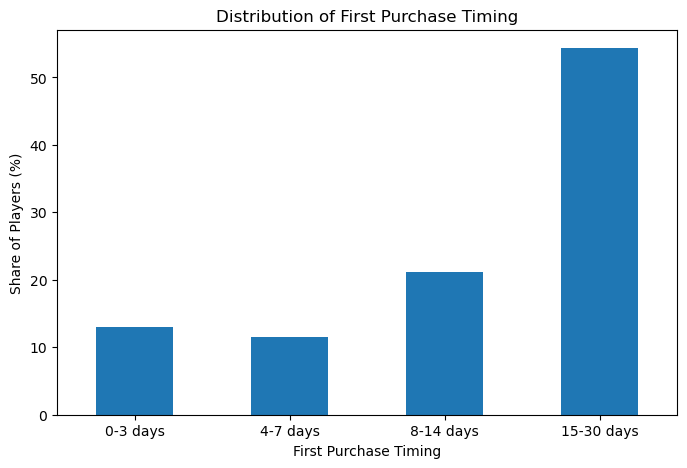

In [101]:
plt.figure(figsize=(8, 5))

first_purchase_distribution.plot(kind="bar")

plt.title("Distribution of First Purchase Timing")
plt.xlabel("First Purchase Timing")
plt.ylabel("Share of Players (%)")
plt.xticks(rotation=0)

plt.show()

## First Purchase Timing x Behavioral Segments

In [102]:
# Now take into account behavioral segments
purchase_timing_segment = pd.crosstab(
    analysis_df["BehavioralSegment"],
    analysis_df["FirstPurchaseTiming"],
    normalize="index"
) * 100

purchase_timing_segment

FirstPurchaseTiming,0-3 days,4-7 days,8-14 days,15-30 days
BehavioralSegment,,,,
High Engagement - High Monetization,11.699164,11.699164,21.309192,55.292479
High Engagement - Low Monetization,13.323782,12.893983,20.057307,53.724928
Low Engagement - High Monetization,12.607450,10.744986,22.063037,54.584527
Low Engagement - Low Monetization,14.225941,10.599721,21.338912,53.835425


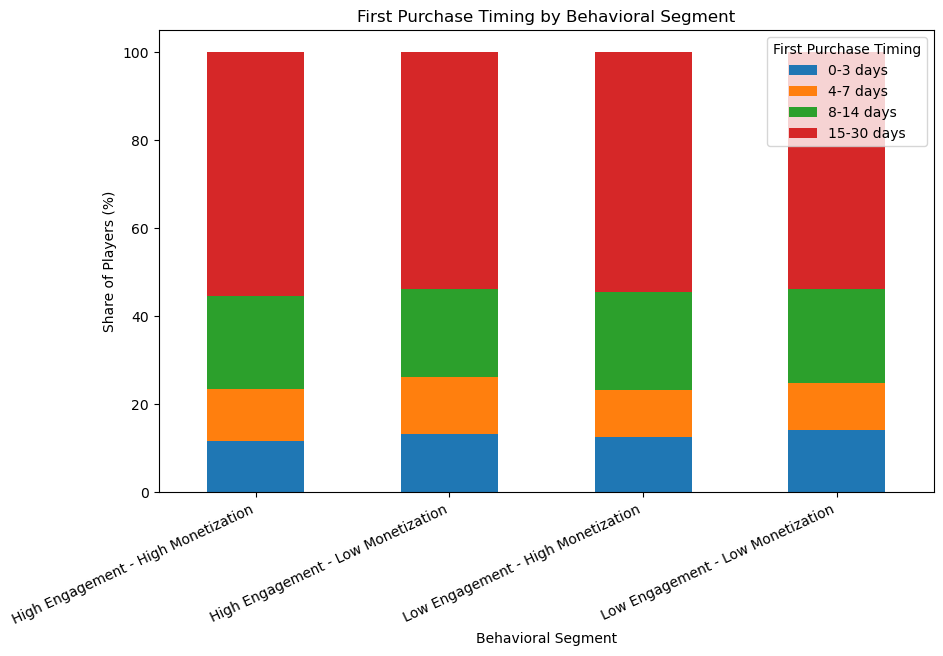

In [103]:
purchase_timing_segment.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("First Purchase Timing by Behavioral Segment")
plt.xlabel("Behavioral Segment")
plt.ylabel("Share of Players (%)")
plt.xticks(rotation=25, ha="right")
plt.legend(title="First Purchase Timing")

plt.show()

## First Purchase Timing x Game Genres

In [104]:
# First Purchase Timing x Genre
genre_purchase_timing = pd.crosstab(
    analysis_df["GameGenre"],
    analysis_df["FirstPurchaseTiming"],
    normalize="index"
) * 100

genre_purchase_timing

FirstPurchaseTiming,0-3 days,4-7 days,8-14 days,15-30 days
GameGenre,,,,
Action RPG,14.673913,11.413043,20.652174,53.260870
Adventure,11.728395,11.111111,22.839506,54.320988
Battle Royale,11.731844,10.055866,24.022346,54.189944
Card,12.820513,8.205128,22.564103,56.410256
Casual,9.900990,13.861386,25.742574,50.495050
Fighting,14.534884,14.534884,12.209302,58.720930
MMORPG,14.361702,10.638298,23.404255,51.595745
MOBA,13.872832,10.404624,17.919075,57.803468
Puzzle,14.871795,12.820513,20.512821,51.794872


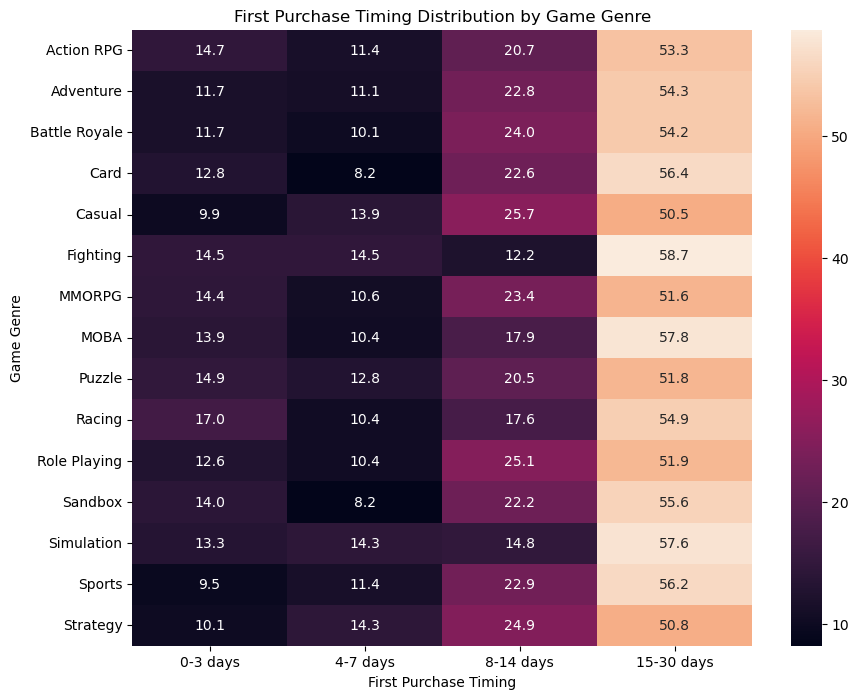

In [105]:
# Game Genra Heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    genre_purchase_timing,
    annot=True,
    fmt=".1f"
)

plt.title("First Purchase Timing Distribution by Game Genre")
plt.xlabel("First Purchase Timing")
plt.ylabel("Game Genre")

plt.show()

## Purchase Recency

In [106]:
analysis_df["LastPurchaseDate"] = pd.to_datetime(analysis_df["LastPurchaseDate"])

reference_date = analysis_df["LastPurchaseDate"].max()

analysis_df["PurchaseRecencyDays"] = (reference_date -
    analysis_df["LastPurchaseDate"]).dt.days

In [107]:
# Create recency groups

analysis_df["PurchaseRecencyGroup"] = pd.cut(
    analysis_df["PurchaseRecencyDays"],
    bins=[-1, 7, 30, 90, np.inf],
    labels=[
        "0–7 days",
        "8–30 days",
        "31–90 days",
        "90+ days"
    ]
)

recency_distribution = (
    analysis_df["PurchaseRecencyGroup"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

recency_distribution

PurchaseRecencyGroup
0–7 days       3.956199
8–30 days     10.455669
31–90 days    26.845638
90+ days      58.742494
Name: proportion, dtype: float64

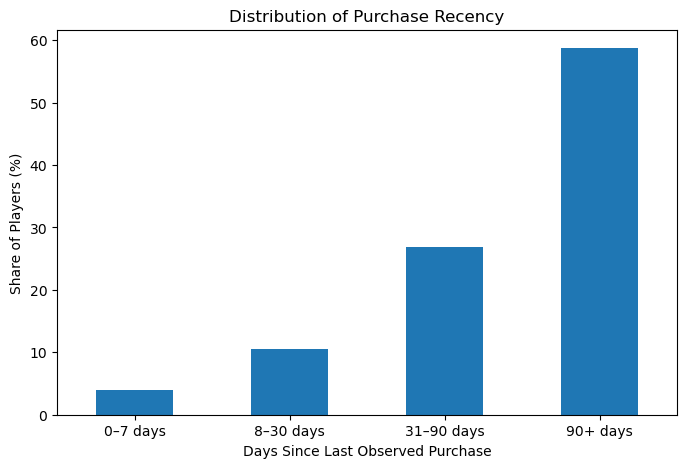

In [108]:
plt.figure(figsize=(8, 5))

recency_distribution.plot(kind="bar")

plt.title("Distribution of Purchase Recency")
plt.xlabel("Days Since Last Observed Purchase")
plt.ylabel("Share of Players (%)")
plt.xticks(rotation=0)

plt.show()

## Purchase Recency x Behavioral Segment

In [109]:
recency_segment = pd.crosstab(
    analysis_df["BehavioralSegment"],
    analysis_df["PurchaseRecencyGroup"],
    normalize="index"
) * 100

recency_segment

PurchaseRecencyGroup,0–7 days,8–30 days,31–90 days,90+ days
BehavioralSegment,,,,
High Engagement - High Monetization,3.621170,10.584958,26.601671,59.192201
High Engagement - Low Monetization,4.011461,9.169054,29.083095,57.736390
Low Engagement - High Monetization,4.297994,10.601719,26.217765,58.882521
Low Engagement - Low Monetization,3.905160,11.436541,25.523013,59.135286


### High Monetization segments have not made any purchases in more than 90+ days.
1. Hypothesis 1: They have already spent much, so they no longer want to spend.
2. Hypothesis 2: Depending on game design
- Incentives are oversufficent so they feel no need to pay.
- No fun live-ents with benefical perks that make they want to pay.

Conclusion: They are high monetization groups, meaning that they are willing to pay. So if we want to drive revenue, we shall re-activate these segments, especially the high engagement segments. 

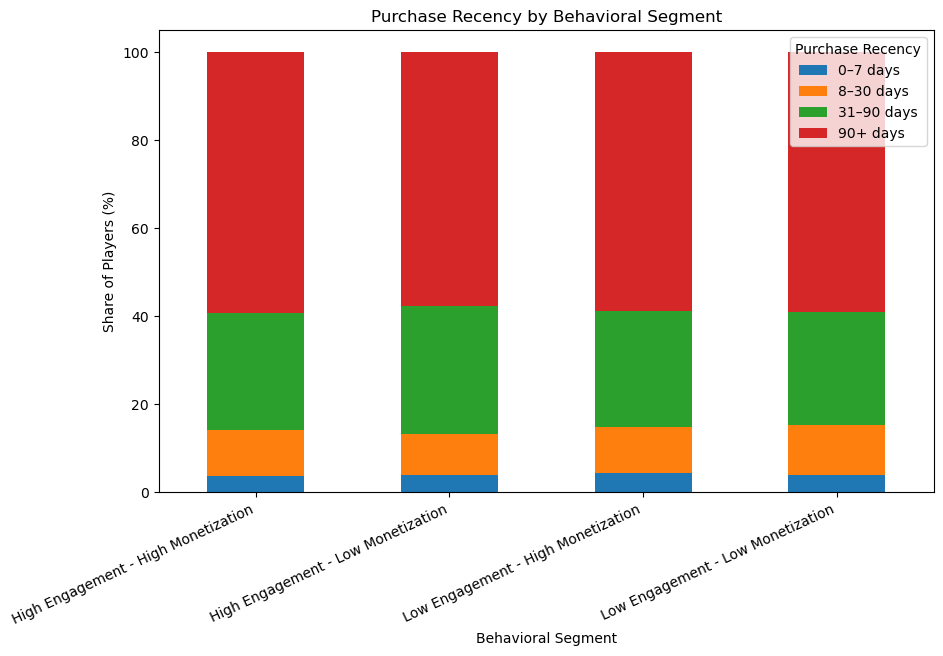

In [110]:
recency_segment.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Purchase Recency by Behavioral Segment")
plt.xlabel("Behavioral Segment")
plt.ylabel("Share of Players (%)")
plt.xticks(rotation=25, ha="right")
plt.legend(title="Purchase Recency")

plt.show()

## First Purchase Timing x Observed Revenue

In [111]:
# Is first-purchase timing associated with different levels of observed revenue?
timing_revenue = (
    analysis_df
    .groupby("FirstPurchaseTiming", observed=True)
    .agg(
        Players=("UserID", "count"),
        MeanRevenue=("InAppPurchaseAmount", "mean"),
        MedianRevenue=("InAppPurchaseAmount", "median")
    )
    .reset_index()
)

timing_revenue

,FirstPurchaseTiming,Players,MeanRevenue,MedianRevenue
0,0-3 days,367,85.112507,11.55
1,4-7 days,325,94.308585,11.81
2,8-14 days,600,126.824883,12.19
3,15-30 days,1539,98.778408,12.16


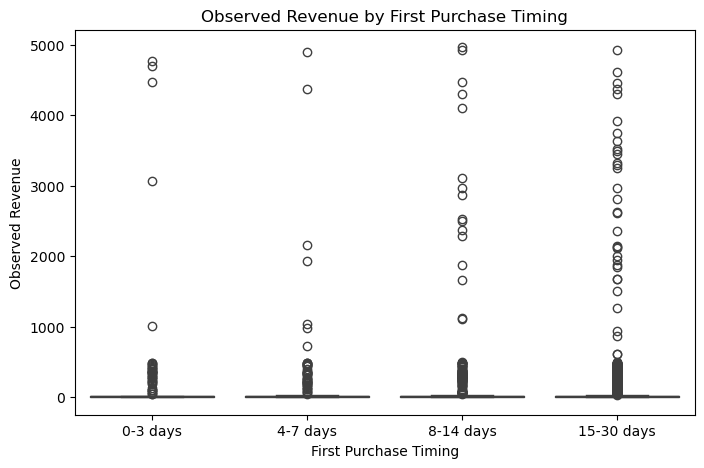

In [112]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=analysis_df,
    x="FirstPurchaseTiming",
    y="InAppPurchaseAmount"
)

plt.title("Observed Revenue by First Purchase Timing")
plt.xlabel("First Purchase Timing")
plt.ylabel("Observed Revenue")

plt.show()

### Hypothesis 1 seems to be more grounded.
If players spend thousands of dollars on the first purchase after playing the game for 15-30 days, they may not want to pay more and keep playing over next months.

## First Purchase Timing x Engagement

In [113]:
timing_engagement = (
    analysis_df
    .groupby("FirstPurchaseTiming", observed=True)
    .agg(
        Players=("UserID", "count"),
        AvgSessionCount=("SessionCount", "mean"),
        AvgSessionLength=("AverageSessionLength", "mean"),
        AvgEngagementScore=("EngagementScore", "mean")
    )
    .reset_index()
)

timing_engagement

,FirstPurchaseTiming,Players,AvgSessionCount,AvgSessionLength,AvgEngagementScore
0,0-3 days,367,10.141689,19.625477,-0.015377
1,4-7 days,325,9.852308,20.372185,-0.018325
2,8-14 days,600,10.176667,20.123383,0.019234
3,15-30 days,1539,10.033138,20.157667,-0.001801


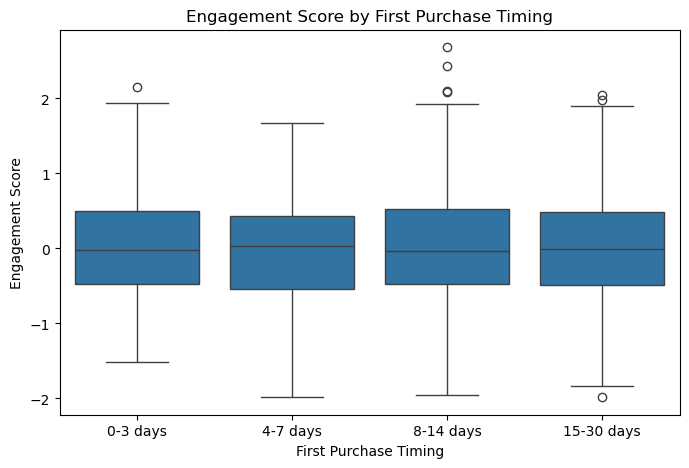

In [114]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=analysis_df,
    x="FirstPurchaseTiming",
    y="EngagementScore"
)

plt.title("Engagement Score by First Purchase Timing")
plt.xlabel("First Purchase Timing")
plt.ylabel("Engagement Score")

plt.show()

## High-Value Player Behavioral Comparison

In [115]:
# What behavioral characteristics distinguish these two high-value player profiles?
high_value_df = analysis_df[
    analysis_df["BehavioralSegment"].isin([
        "High Engagement - High Monetization",
        "Low Engagement - High Monetization"
    ])
].copy()

In [116]:
# Compare first purchase timing
high_value_purchase_timing = pd.crosstab(
    high_value_df["BehavioralSegment"],
    high_value_df["FirstPurchaseTiming"],
    normalize="index"
) * 100

high_value_purchase_timing

FirstPurchaseTiming,0-3 days,4-7 days,8-14 days,15-30 days
BehavioralSegment,,,,
High Engagement - High Monetization,11.699164,11.699164,21.309192,55.292479
Low Engagement - High Monetization,12.607450,10.744986,22.063037,54.584527


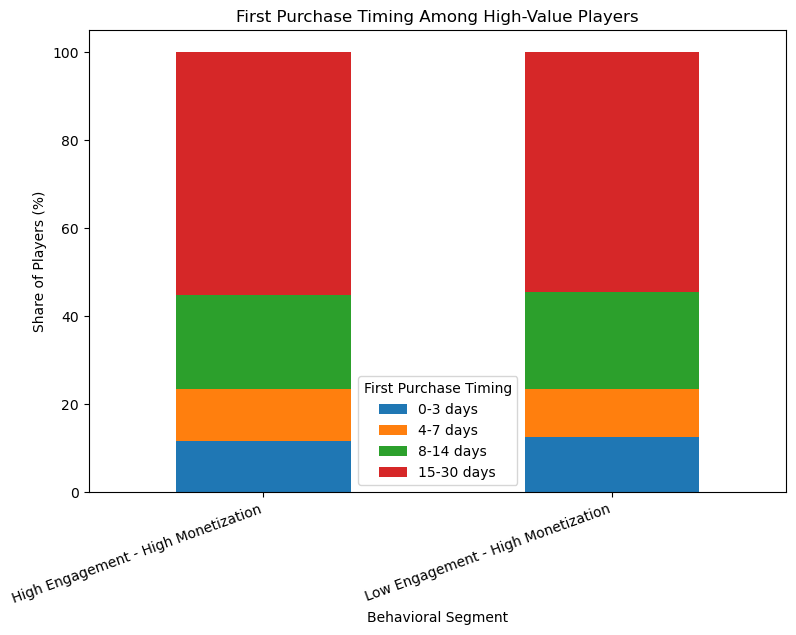

In [130]:
high_value_purchase_timing.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 6)
)

plt.title("First Purchase Timing Among High-Value Players")
plt.xlabel("Behavioral Segment")
plt.ylabel("Share of Players (%)")
plt.xticks(rotation=20, ha="right")
plt.legend(title="First Purchase Timing")

plt.show()

In [ ]:
# Compare purchase recency
high_value_recency = pd.crosstab(
    high_value_df["BehavioralSegment"],
    high_value_df["PurchaseRecencyGroup"],
    normalize="index"
) * 100

high_value_recency

PurchaseRecencyGroup,0–7 days,8–30 days,31–90 days,90+ days
BehavioralSegment,,,,
High Engagement - High Monetization,3.621170,10.584958,26.601671,59.192201
Low Engagement - High Monetization,4.297994,10.601719,26.217765,58.882521


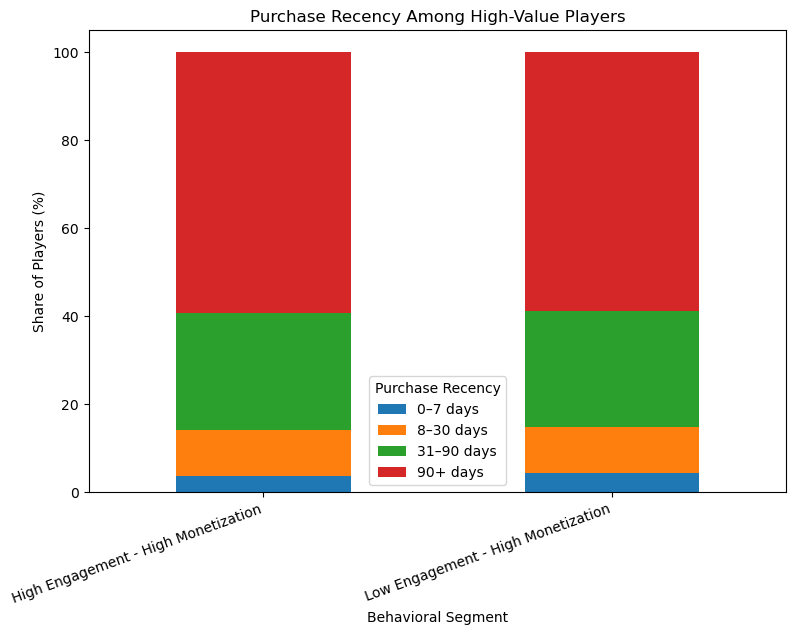

In [118]:
high_value_recency.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 6)
)

plt.title("Purchase Recency Among High-Value Players")
plt.xlabel("Behavioral Segment")
plt.ylabel("Share of Players (%)")
plt.xticks(rotation=20, ha="right")
plt.legend(title="Purchase Recency")

plt.show()

In [119]:
# Compare engagement components
high_value_engagement = (
    high_value_df
    .groupby("BehavioralSegment")
    .agg(
        AvgSessionCount=("SessionCount", "mean"),
        MedianSessionCount=("SessionCount", "median"),
        AvgSessionLength=("AverageSessionLength", "mean"),
        MedianSessionLength=("AverageSessionLength", "median")
    )
    .reset_index()
)

high_value_engagement


,BehavioralSegment,AvgSessionCount,MedianSessionCount,AvgSessionLength,MedianSessionLength
0,High Engagement - High Monetization,11.688022,12.0,25.436031,26.675
1,Low Engagement - High Monetization,8.469914,9.0,14.754026,13.790


In [120]:
# Compare spending segment
high_value_spending = pd.crosstab(
    high_value_df["BehavioralSegment"],
    high_value_df["SpendingSegment"],
    normalize="index"
) * 100

high_value_spending

SpendingSegment,Dolphin,Minnow,Whale
BehavioralSegment,,,
High Engagement - High Monetization,27.298050,68.802228,3.899721
Low Engagement - High Monetization,26.790831,68.338109,4.871060


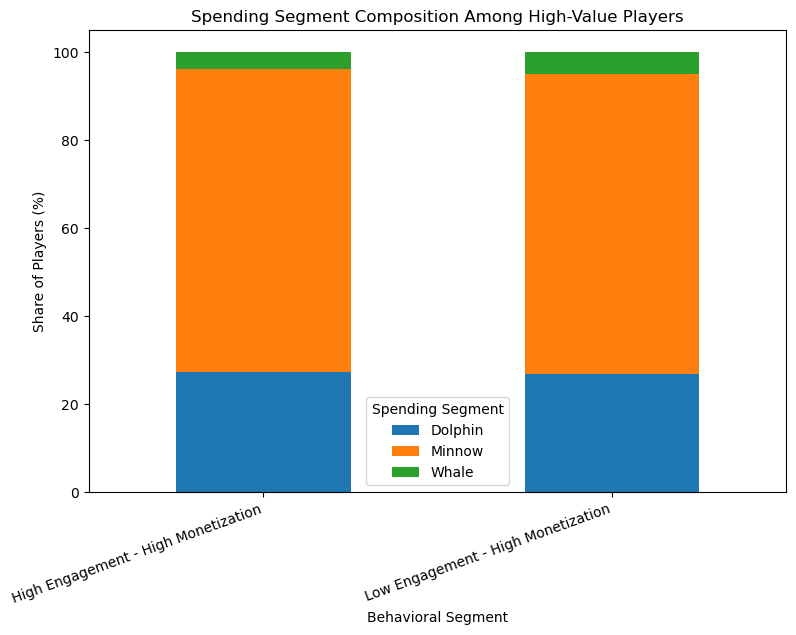

In [121]:
high_value_spending.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 6)
)

plt.title("Spending Segment Composition Among High-Value Players")
plt.xlabel("Behavioral Segment")
plt.ylabel("Share of Players (%)")
plt.xticks(rotation=20, ha="right")
plt.legend(title="Spending Segment")

plt.show()

In [122]:
# Compare game genre within high-value players
high_value_genre = pd.crosstab(
    high_value_df["GameGenre"],
    high_value_df["BehavioralSegment"],
    normalize="index"
) * 100

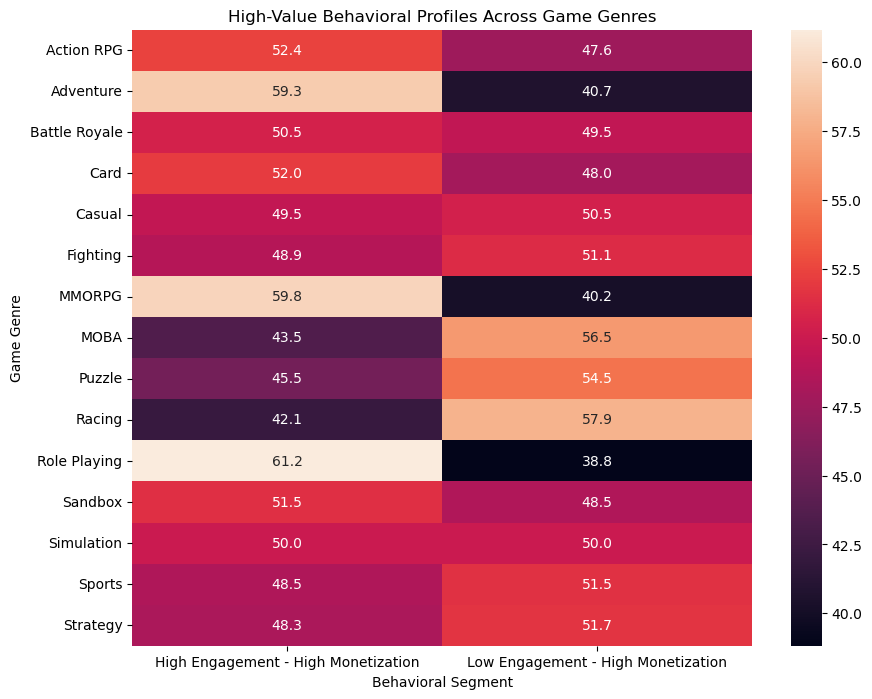

In [123]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    high_value_genre,
    annot=True,
    fmt=".1f"
)

plt.title("High-Value Behavioral Profiles Across Game Genres")
plt.xlabel("Behavioral Segment")
plt.ylabel("Game Genre")

plt.show()

### Contrasting numbers
- Adventure
- MMORPG
- MOBA
- Puzzle
- Racing
- Role Playing

#### Finding:
- The composition of high-monetization players varies across genres. 
- In several genres, high-monetization players are more frequently highly engaged, while Puzzle shows a relatively greater representation of the Low Engagement–High Monetization profile. 

**This suggests that the relationship between engagement and monetization may differ by genre.**

## Behavioral Contrasts
Look at some noticeable "outlier" patterns:
- High engagement but unusally low revenue
- Low engagment but unusally high revenue

In [127]:
low_value_high_engagement = analysis_df[
    (analysis_df["EngagementScore"] >= analysis_df["EngagementScore"].quantile(0.75)) &
    (analysis_df["InAppPurchaseAmount"] <= analysis_df["InAppPurchaseAmount"].quantile(0.25))
]

print(f"Show me the number: {len(low_value_high_engagement)}")

Show me the number: 191


In [128]:
high_value_low_engagement = analysis_df[
    (analysis_df["EngagementScore"] <= analysis_df["EngagementScore"].quantile(0.25)) &
    (analysis_df["InAppPurchaseAmount"] >= analysis_df["InAppPurchaseAmount"].quantile(0.75))
]

print(f"Show me the number: {len(high_value_low_engagement)}")

Show me the number: 175


In [129]:
outlier_summary = pd.DataFrame({
    "Group": [
        "High Engagement / Low Revenue",
        "Low Engagement / High Revenue"
    ],
    "Players": [
        len(low_value_high_engagement),
        len(high_value_low_engagement)
    ],
    "AvgFirstPurchaseDays": [
        low_value_high_engagement["FirstPurchaseDaysAfterInstall"].mean(),
        high_value_low_engagement["FirstPurchaseDaysAfterInstall"].mean()
    ],
    "AvgRecencyDays": [
        low_value_high_engagement["PurchaseRecencyDays"].mean(),
        high_value_low_engagement["PurchaseRecencyDays"].mean()
    ],
    "AvgSessionCount": [
        low_value_high_engagement["SessionCount"].mean(),
        high_value_low_engagement["SessionCount"].mean()
    ],
    "AvgSessionLength": [
        low_value_high_engagement["AverageSessionLength"].mean(),
        high_value_low_engagement["AverageSessionLength"].mean()
    ]
})

outlier_summary

,Group,Players,AvgFirstPurchaseDays,AvgRecencyDays,AvgSessionCount,AvgSessionLength
0,High Engagement / Low Revenue,191,15.230366,106.722513,13.073298,27.444398
1,Low Engagement / High Revenue,175,15.937143,111.125714,7.491429,11.824171


## Key findings:

### 1. First-purchase timing is concentrated in the 15–30-day window

- First-purchase timing was concentrated in the 15–30-day window: 1,539 of 2,831 players (54.4%) in the purchase-observed analytical population made their first observed purchase during this period. 
- This pattern was consistent across behavioral segments, where the 15–30-day group accounted for 53.7%–55.3% of players, and across game genres, where the share ranged from 50.5% to 58.7%. 

> This suggests that first-purchase timing is relatively consistent across the player profiles and genres examined.

### 2. Earlier first purchases do not consistently correspond to higher observed revenue

- Players whose first observed purchase occurred 8–14 days after installation had the highest mean observed revenue ($126.82), compared with $98.78 among players purchasing during days 15–30. 
- However, their median revenues were nearly identical ($12.19 vs. $12.16), suggesting that the higher mean in the 8–14-day group may be influenced by a relatively small number of high-spending players. 

> Therefore, first-purchase timing alone does not appear to provide a straightforward indicator of typical player monetization.

### 3. Long purchase recency is widespread, including among high-monetization players

- Purchase recency was heavily skewed toward older purchases: 58.7% of players had their last observed purchase more than 90 days before the dataset reference date. 
- This pattern was also consistent across behavioral segments, with 57.7%–59.2% of players in each segment falling into the 90+ day group. Notably, the rate was similarly high among both High Engagement–High Monetization players (59.2%) and Low Engagement–High Monetization players (58.9%). 

> This suggests that long purchase recency is not unique to lower-value players and may warrant further investigation among high-monetization profiles.

### 4. Engagement and monetization can diverge substantially

- The behavioral contrast analysis indeed identified the two groups' substantial difference in engagement: High Engagement–Low Revenue players averaged 13.07 sessions and 27.44 minutes per session, compared with 7.49 sessions and 11.82 minutes for Low Engagement–High Revenue players. 
- However, their average first-purchase timing (15.23 vs. 15.94 days) and purchase recency (106.72 vs. 111.13 days) were relatively similar. 

> This reinforces the earlier finding that higher engagement does not necessarily correspond to higher observed monetization in this dataset.

### 5. The analysis generates hypotheses, rather than establishing causes

- The observed long purchase recency among high-monetization players raises several hypotheses, including whether previous high-value purchases reduce subsequent purchase need or whether the current game incentive structure provides limited reasons for repeat spending. 
- These explanations cannot be established with the available player-level data and would require additional transaction-level, gameplay, inventory, and live-event data to test.